# torchvision

- 이미지 처리 작업을 단순화하여, 보다 쉽게 데이터 전처리 및 증강을 할 수 있도록 돕는다.  

- Datasets(데이터셋): 여러 유명한 이미지 데이터셋을 손쉽게 불러올 수 있다. 
- Transforms(변환): 이미지 데이터를 전처리하고 변환할 수 있는 다양한 기법들을 제공 
    - Data Augmentation과 Preprocessing에 유용
- Models(모델): 사전 학습된 (pre-trained) 여러 이미지 분류 모델을 제공 
    - ResNet, VGG, AlexNet 등
- Utils(유틸리티): 이미지 처리와 관련된 다양한 유틸리티 함수들을 제공 
    - 이를 통해 이미지 입출력, 시각화 등을 쉽게 수행 

## torchvision 기능과 활용방법 



In [1]:
import torchvision.datasets as datasets

train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=None  # 이미지 변환(transformations)은 나중에 적용
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=None
)

print(f'Training set size: {len(train_dataset)}')
print(f'Test set size: {len(test_dataset)}')

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.60MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 107kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 818kB/s]

Training set size: 60000
Test set size: 10000


Sample 1
Label: 9


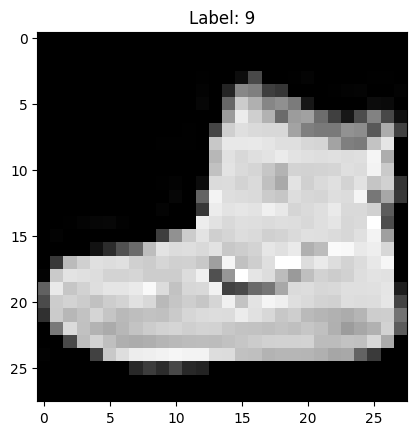

Sample 2
Label: 0


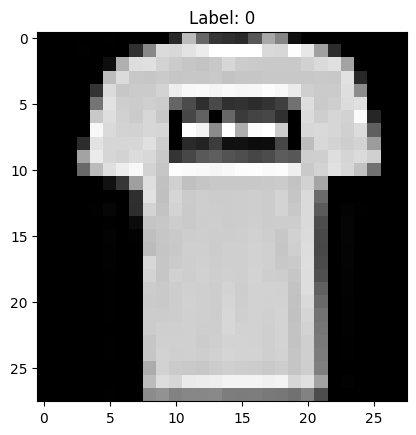

Sample 3
Label: 0


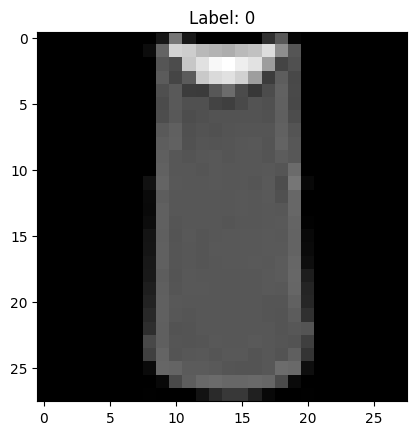

In [2]:
#시각화
import matplotlib.pyplot as plt

# 여러 샘플 확인
for i in range(3):
    image, label = train_dataset[i]
    print(f'Sample {i + 1}')
    print(f'Label: {label}')
    plt.imshow(image, cmap='gray')
    plt.title(f'Label: {label}')
    plt.show()

## Transforms

In [3]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 텐서로 변환
])

train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform  # train 이미지 변환 적용
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform # test 이미지 변환 적용
)

## Model

In [5]:
import torchvision.models as models

resnet18 = models.resnet18(pretrained=True)
# Resnet-18 model을 로드 
# 사전 학습된 가중치를 사용하여 모델을 로드, 
# 이를 통해 사용자는 사전 학습된 모델을 기반으로 추가 학습(fine-tuning)하거나, 
# 특정 작업에 맞게 모델을 수정할 수 있습니다.

# Utils

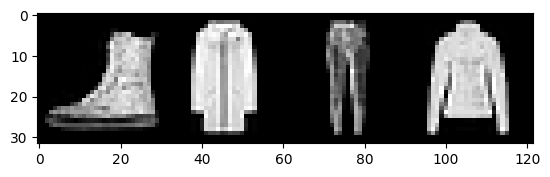

In [7]:
import torchvision.utils as utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 이미지를 격자 형태로 결합하여 시각화
def show(img):
    npimg = img.numpy()
    #이미지를 넘파이 배열로 변환하고, matplotlib를 사용하여 시각화
    #np.transpose(npimg, (1, 2, 0))를 사용하여 이미지의 차원을 변경하고,
    # plt.imshow()를 사용하여 이미지를 표시합니다.
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.show()

# Fashion MNIST 데이터셋 로드 및 변환 정의
transform = transforms.Compose([
    transforms.ToTensor()
])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# 첫 번째 배치의 이미지를 격자로 결합하여 시각화
dataiter = iter(dataloader) #데이터로더에서 배치를 가져올수 있는 이터레이터를 생성
images, labels = next(dataiter) 
#첫번째 배치를 가져온다. 여기서 images는 이미지 텐서
#labels는 해당 이미지의 레이블을 나타내는 텐서입니다.
img_grid = utils.make_grid(images)
#여러 이미지를 격자 형태로 결합하여 하나의 이미지로 만든다. 
#torchvision.utils 모듈의 기능으로, 이미지의 미니 배치를 시각화할 때 유용 
show(img_grid)